In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/raw/Iris.csv", sep=",")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.shape

(150, 6)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Species"].unique()


<ArrowStringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str

In [8]:
df["Sepal_Area"] = df["SepalLengthCm"] * df["SepalWidthCm"]
df["Petal_Area"] = df["PetalLengthCm"] * df["PetalWidthCm"]

In [9]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Sepal_Area,Petal_Area
0,1,5.1,3.5,1.4,0.2,Iris-setosa,17.85,0.28
1,2,4.9,3.0,1.4,0.2,Iris-setosa,14.70,0.28
2,3,4.7,3.2,1.3,0.2,Iris-setosa,15.04,0.26
3,4,4.6,3.1,1.5,0.2,Iris-setosa,14.26,0.30
4,5,5.0,3.6,1.4,0.2,Iris-setosa,18.00,0.28


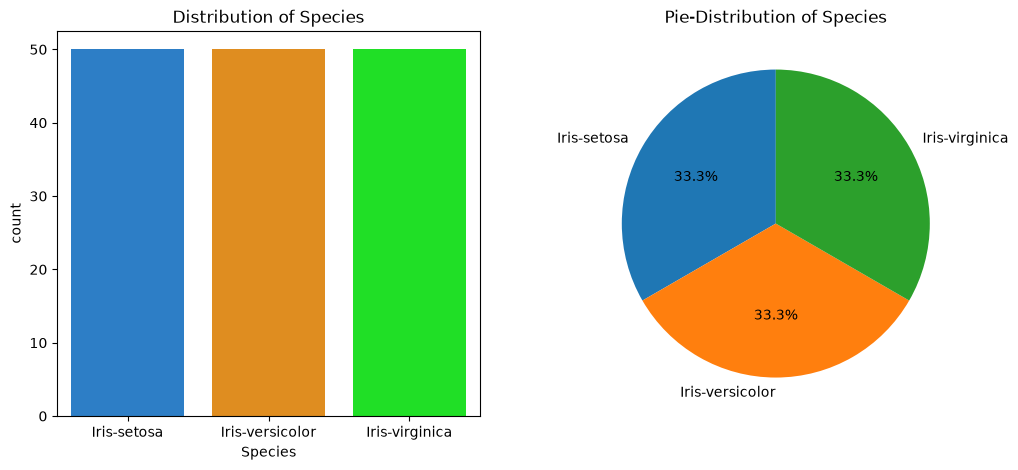

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))
axes = axes.flatten()

sns.countplot(x="Species", data=df, ax= axes[0], palette=["#1480df", "#ff9100", "#00ff08"])
axes[0].set_title("Distribution of Species")

axes[1].pie(df['Species'].value_counts(), labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Pie-Distribution of Species")    

plt.show()


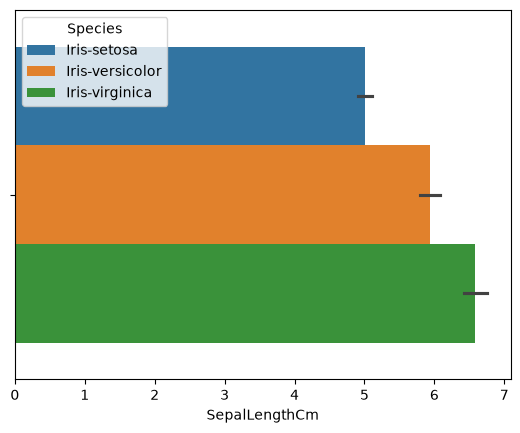

In [11]:
sns.barplot(x="SepalLengthCm", hue="Species", data=df)
plt.show()

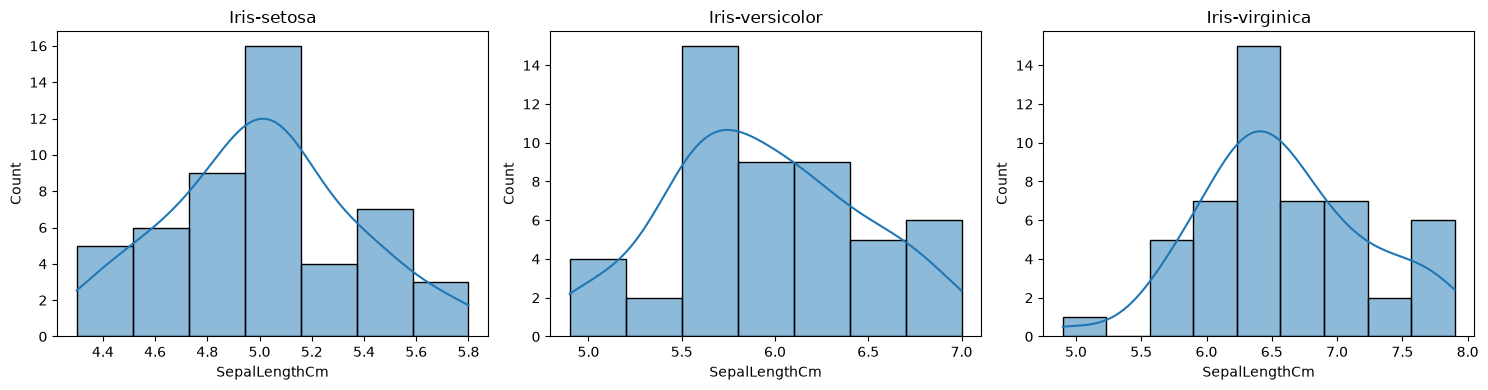

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

for i, sp in enumerate(species):
    sns.histplot(
        data=df[df["Species"] == sp],
        x="SepalLengthCm",
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(sp)

plt.tight_layout()
plt.show()

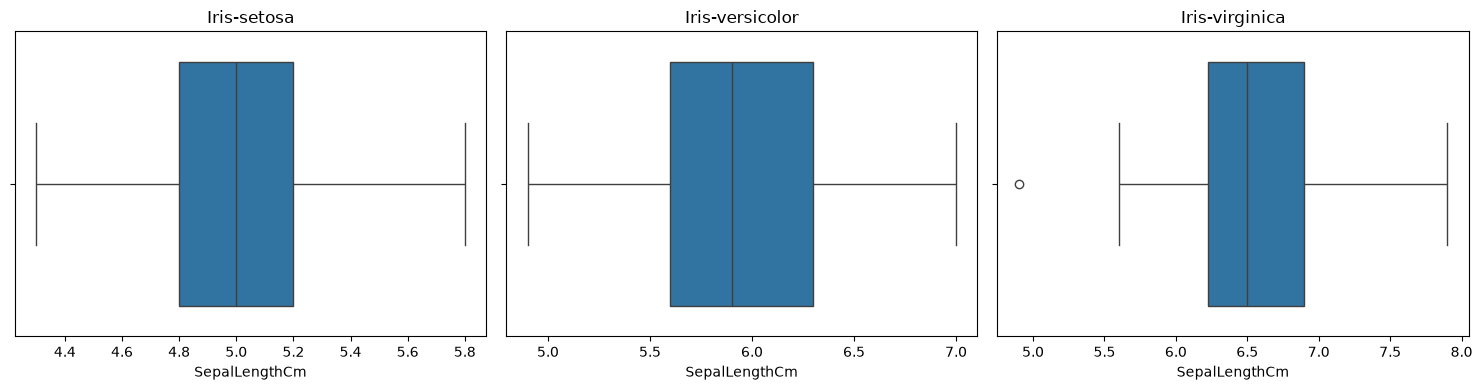

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

species = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

for i, sp in enumerate(species):
    sns.boxplot(
        data=df[df["Species"] == sp],
        x="SepalLengthCm",
        ax=axes[i]
    )
    axes[i].set_title(sp)

plt.tight_layout()
plt.show()

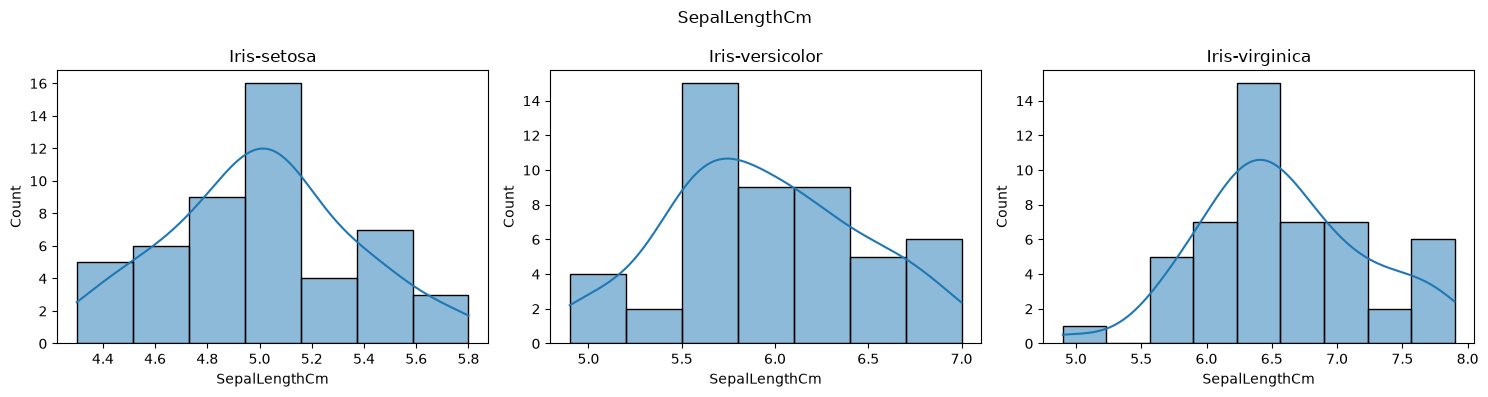

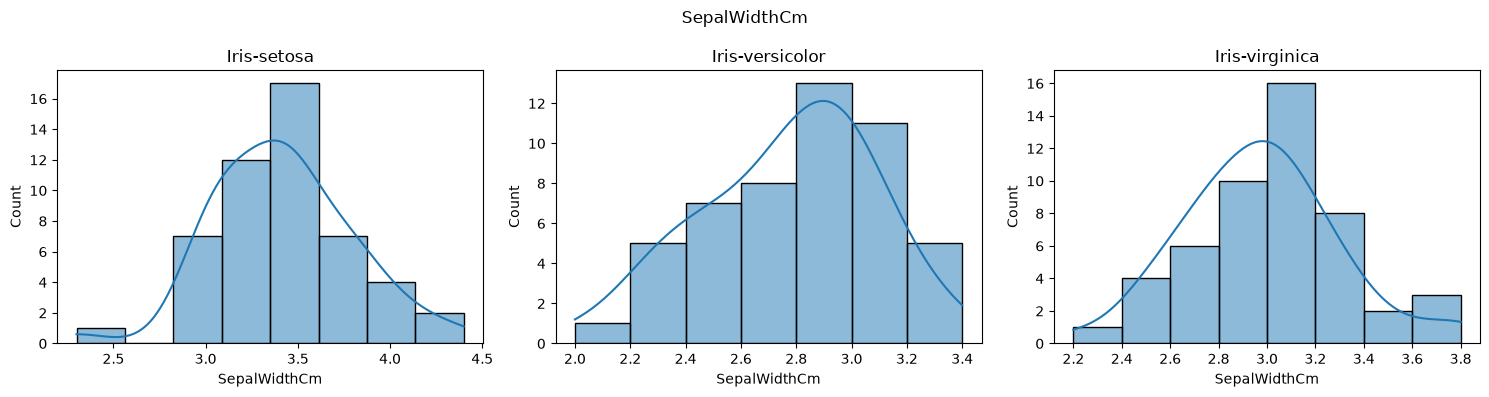

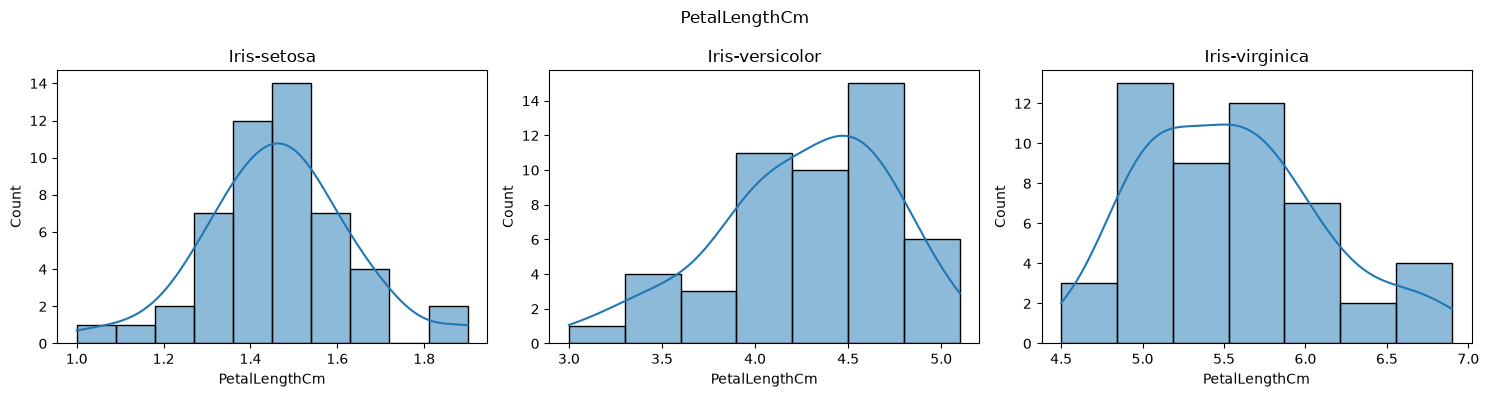

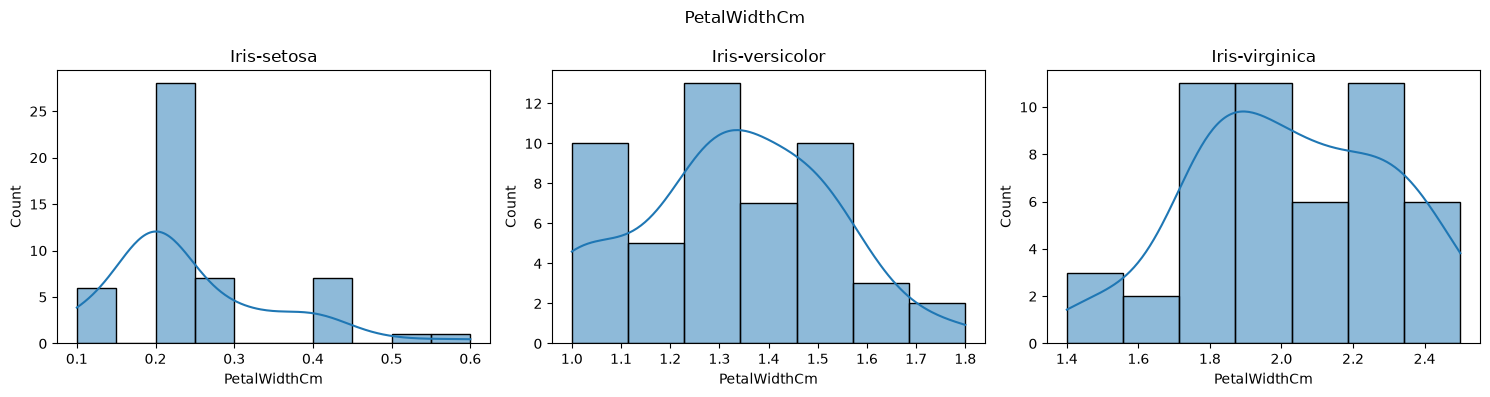

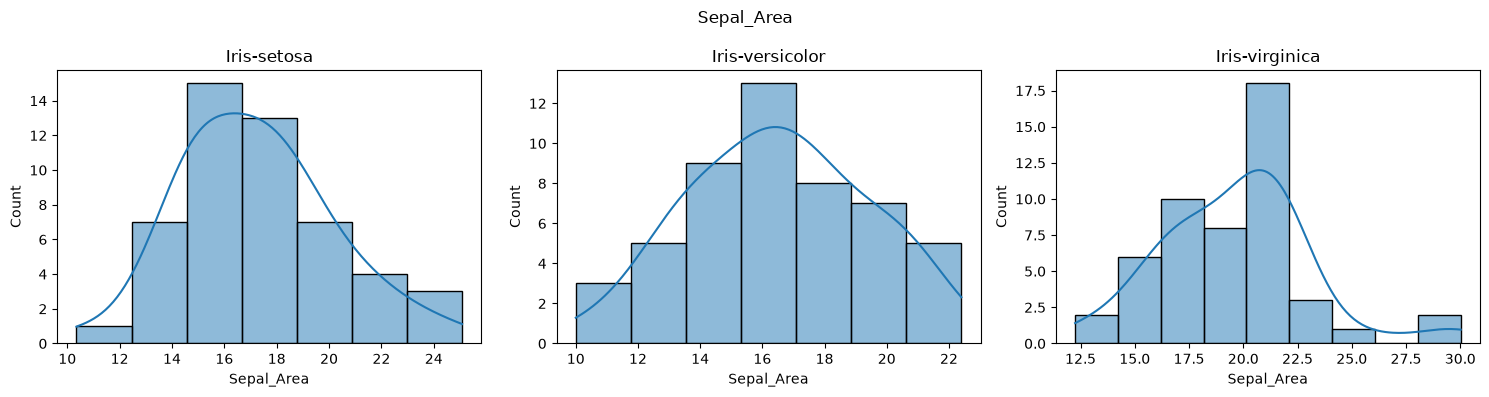

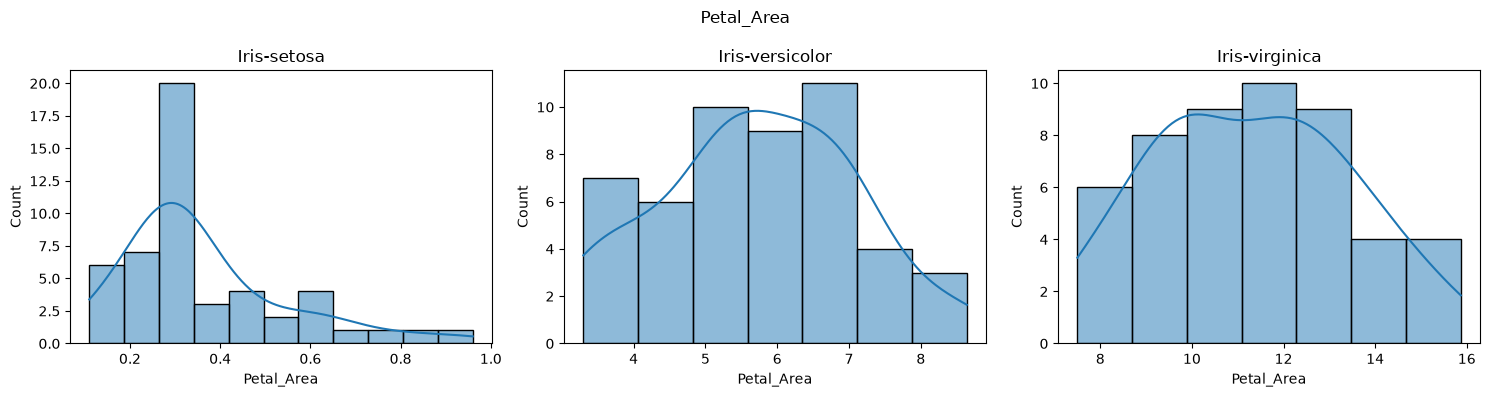

In [14]:
features = df.columns.drop(["Species", "Id"])

for feature in features:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, sp in enumerate(species):
        sns.histplot(
            data=df[df["Species"] == sp],
            x=feature,
            kde=True,
            ax=axes[i]
        )
        axes[i].set_title(sp)

    fig.suptitle(feature)
    plt.tight_layout()
    plt.show()

In [15]:
df_transformed = df.copy()

In [16]:
le = LabelEncoder()

df_transformed["Species"] = le.fit_transform(df_transformed['Species'])

In [17]:
df_transformed["Species"].unique()

array([0, 1, 2])

In [18]:
for label, species in enumerate(le.classes_):
    print(f"{species} -> {label}")

Iris-setosa -> 0
Iris-versicolor -> 1
Iris-virginica -> 2


In [19]:
### Selecting feature for X and target for y

X = df_transformed.drop(["Species", "Id"], axis=1)
y = df_transformed["Species"]

In [20]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Sepal_Area,Petal_Area
0,5.1,3.5,1.4,0.2,17.85,0.28
1,4.9,3.0,1.4,0.2,14.70,0.28
2,4.7,3.2,1.3,0.2,15.04,0.26
3,4.6,3.1,1.5,0.2,14.26,0.30
4,5.0,3.6,1.4,0.2,18.00,0.28


In [21]:
X.shape, y.shape

((150, 6), (150,))

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
    )

In [ ]:
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score, confusion_matrix

In [24]:
models = {
    "LR" : LogisticRegression(random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "AdaBoostClassifier" : AdaBoostClassifier(n_estimators=100),
    "GradientBoostingClassifier": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42, n_estimators=100),
    "GB": GaussianNB(),
    "SVC": SVC(),
    "XGboost": XGBClassifier(),
}

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

results = []
cmf_results = []
classification_result = []

for name, model in models.items():

    # Train on training set
    model.fit(X_train, y_train)

    # Test set predictions
    y_pred = model.predict(X_test)

    # Evaluation metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cmf = confusion_matrix(y_test,y_pred)
    crt = classification_report(y_test,y_pred, output_dict=True)

    # 5-Fold Cross Validation on full dataset
    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy'
    )

    results.append({
        "name": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    })
    
    cmf_results.append({
    "name": name,
    "confusion" : cmf
    })
    
    classification_result.append({
    "name": name,
    "classification" : crt
    })


<Figure size 500x500 with 0 Axes>

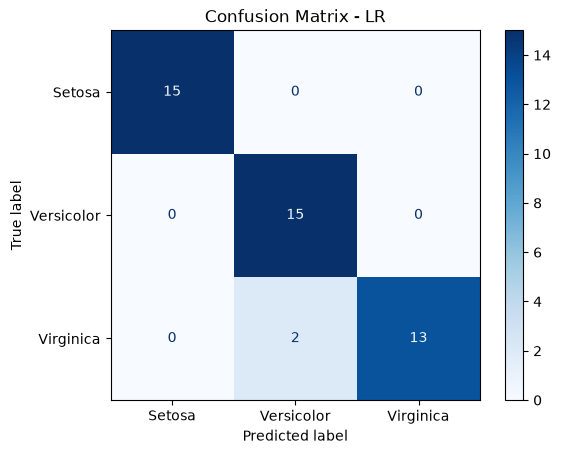

<Figure size 500x500 with 0 Axes>

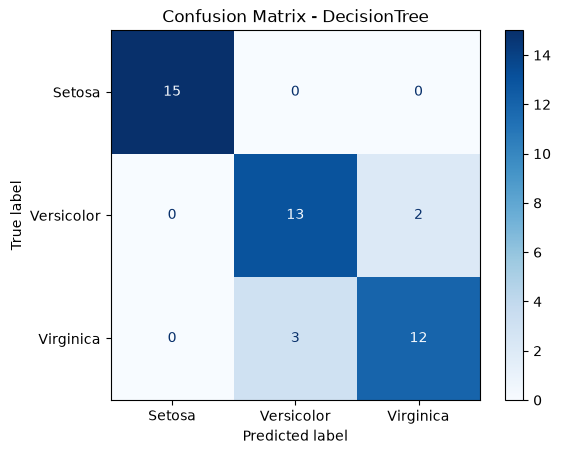

<Figure size 500x500 with 0 Axes>

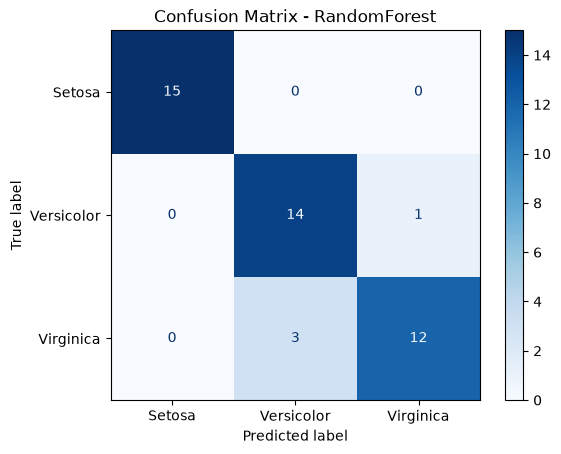

<Figure size 500x500 with 0 Axes>

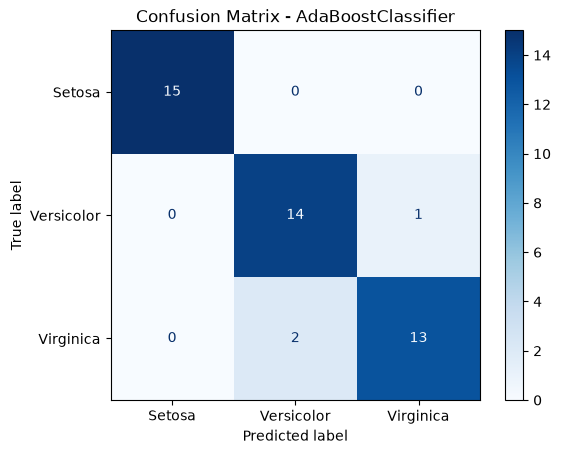

<Figure size 500x500 with 0 Axes>

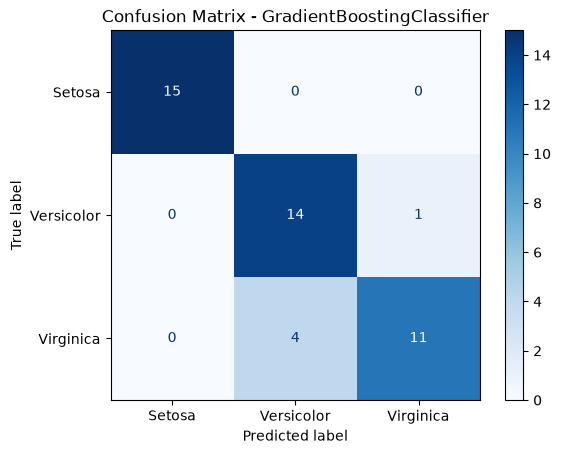

<Figure size 500x500 with 0 Axes>

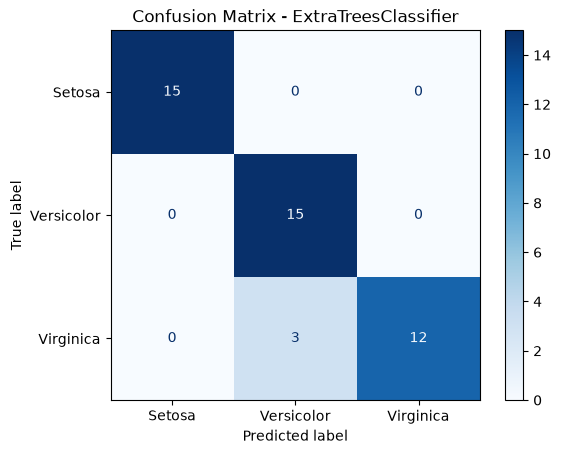

<Figure size 500x500 with 0 Axes>

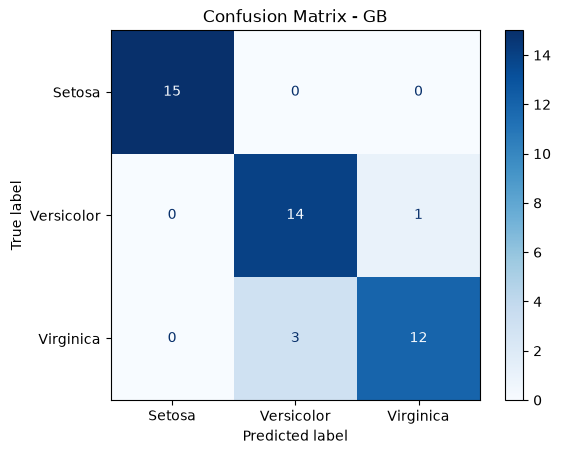

<Figure size 500x500 with 0 Axes>

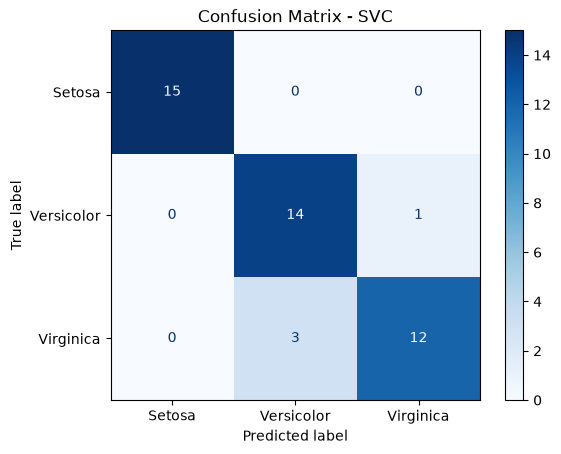

<Figure size 500x500 with 0 Axes>

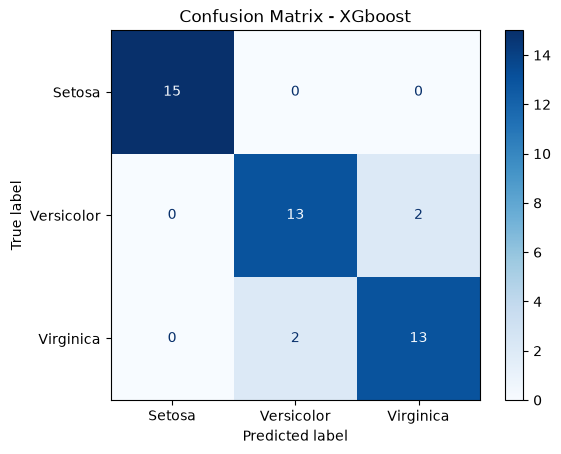

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay


class_names = ["Setosa", "Versicolor", "Virginica"]

for item in cmf_results:
    plt.figure(figsize=(5, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=item["confusion"],
        display_labels=class_names
    )

    disp.plot(cmap="Blues", values_format='d')
    plt.title(f"Confusion Matrix - {item['name']}")
    plt.show()

In [27]:
for item in classification_result:
    df_report = pd.DataFrame(item["classification"]).transpose()

    print(f"\n{item['name']}")
    display(df_report.round(2))


LR


,precision,recall,f1-score,support
0,1.00,1.00,1.00,15.00
1,0.88,1.00,0.94,15.00
2,1.00,0.87,0.93,15.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,45.00
weighted avg,0.96,0.96,0.96,45.00



DecisionTree


,precision,recall,f1-score,support
0,1.00,1.00,1.00,15.00
1,0.81,0.87,0.84,15.00
2,0.86,0.80,0.83,15.00
accuracy,0.89,0.89,0.89,0.89
macro avg,0.89,0.89,0.89,45.00
weighted avg,0.89,0.89,0.89,45.00



RandomForest


...

,precision,recall,f1-score,support
0,1.00,1.00,1.00,15.00
1,0.82,0.93,0.88,15.00
2,0.92,0.80,0.86,15.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.92,0.91,0.91,45.00
weighted avg,0.92,0.91,0.91,45.00



SVC


,precision,recall,f1-score,support
0,1.00,1.00,1.00,15.00
1,0.82,0.93,0.88,15.00
2,0.92,0.80,0.86,15.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.92,0.91,0.91,45.00
weighted avg,0.92,0.91,0.91,45.00



XGboost


,precision,recall,f1-score,support
0,1.00,1.00,1.00,15.00
1,0.87,0.87,0.87,15.00
2,0.87,0.87,0.87,15.00
accuracy,0.91,0.91,0.91,0.91
macro avg,0.91,0.91,0.91,45.00
weighted avg,0.91,0.91,0.91,45.00


In [28]:

results_df = pd.DataFrame(results)

results_df

,name,accuracy,precision,recall,f1,cv_mean,cv_std
0,LR,0.955556,0.960784,0.955556,0.955357,0.973333,0.032660
1,DecisionTree,0.888889,0.889881,0.888889,0.888765,0.960000,0.038873
2,RandomForest,0.911111,0.915535,0.911111,0.910714,0.966667,0.021082
3,AdaBoostClassifier,0.933333,0.934524,0.933333,0.933259,0.960000,0.032660
4,GradientBoostingClassifier,0.888889,0.898148,0.888889,0.887767,0.946667,0.040000
5,ExtraTreesClassifier,0.933333,0.944444,0.933333,0.932660,0.953333,0.033993
6,GB,0.911111,0.915535,0.911111,0.910714,0.946667,0.033993
7,SVC,0.911111,0.915535,0.911111,0.910714,0.966667,0.036515
8,XGboost,0.911111,0.911111,0.911111,0.911111,0.953333,0.016330


In [29]:
results_df.sort_values(
    by=["cv_mean", "cv_std"],
    ascending=[False, True],
)

,name,accuracy,precision,recall,f1,cv_mean,cv_std
0,LR,0.955556,0.960784,0.955556,0.955357,0.973333,0.032660
2,RandomForest,0.911111,0.915535,0.911111,0.910714,0.966667,0.021082
7,SVC,0.911111,0.915535,0.911111,0.910714,0.966667,0.036515
3,AdaBoostClassifier,0.933333,0.934524,0.933333,0.933259,0.960000,0.032660
1,DecisionTree,0.888889,0.889881,0.888889,0.888765,0.960000,0.038873
8,XGboost,0.911111,0.911111,0.911111,0.911111,0.953333,0.016330
5,ExtraTreesClassifier,0.933333,0.944444,0.933333,0.932660,0.953333,0.033993
6,GB,0.911111,0.915535,0.911111,0.910714,0.946667,0.033993
4,GradientBoostingClassifier,0.888889,0.898148,0.888889,0.887767,0.946667,0.040000


In [30]:
model = joblib.dump(models['LR'], open("../artifacts/model/best_model.pkl", "wb") )

In [31]:
model = joblib.load("../artifacts/model/best_model.pkl")

In [32]:
print(model)
print(type(model))

LogisticRegression(random_state=42)
<class 'sklearn.linear_model._logistic.LogisticRegression'>
